In [2]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
from scipy.optimize import curve_fit
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
np.set_printoptions(legacy='1.25')

h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [3]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
e=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [4]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = np.unique(magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1))

print(np.array(btunes))
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))
print(ket1_1basis.kets)

[ 4.44616645  5.94607803  8.94590118 18.26678025]
[-0.5  0.5]
[KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Rb:58,P_1/2,1/2)]


In [28]:
b_index = 1

# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets:
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[1]
tuple1 = ket1_tuples[0]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(ket_tuples)


4
((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2)))


In [29]:
# setting target and resonant states
ket_tuples = [tuple0, tuple1]
# ket_tuples = []
# for tuple0 in ket0_tuples:
#     for tuple1 in ket1_tuples:
#         ket_tuples.append(tuple0)
#         ket_tuples.append(tuple1)

eff_system = pi.EffectiveSystemPair(ket_tuples)
# eff_system.set_minimum_number_of_ket_pairs(1)
# eff_system.set_maximum_number_of_ket_pairs(10)
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
# bs = np.linspace(0, max(btunes), 100)

print(bs)

eff_h = eff_system.get_effective_hamiltonian(unit="MHz")
# eff_h -= np.eye(2) * eff_system.get_pair_energies("MHz")[1]

eff_system.set_diamagnetism_enabled(True)
eff_system.set_minimum_number_of_ket_pairs(4000)
eff_system.set_maximum_number_of_ket_pairs(5000)

theta = 0
thetas = [0, 45, 90]
elec=0
rs = np.linspace(1, 100, 500)


figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\2x2 hams\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\2x2 hams\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)  

for theta in thetas:
    for mag in bs:
        if not os.path.exists(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {np.round(theta,3)}deg, mag {np.round(mag,3)}G, e {np.round(e,3)}Vcm.csv'):
            eff_h_dict_elements = {'rs' : rs, '00' : [], '01' : [], '10' : [], '11' : []}

            eff_system.set_magnetic_field([0,0,mag], unit='G').set_electric_field([0, 0, elec], unit='V/cm')
            pair_energy_pm = eff_system.get_pair_energies("MHz")[0]

            # for each theta
            for r in rs:
                eff_system.set_distance(r, theta, "micrometer")
                
                H = eff_system.get_effective_hamiltonian(unit="MHz") - pair_energy_pm * np.eye(2)
                eff_h_dict_elements["00"].append(H[0,0])
                eff_h_dict_elements["01"].append(H[0,1])
                eff_h_dict_elements["10"].append(H[1,0])
                eff_h_dict_elements["11"].append(H[1,1])

            pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {np.round(theta,3)}deg, mag {np.round(mag,3)}G, e {np.round(e,3)}Vcm.csv', index=False)


[ 0.          4.44616645  5.94607803  8.94590118 18.26678025]


The ket |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,1/2⟩ with overlap 7.071e-01
  - |Rb:58,P_1/2,1/2; Cs:57,P_1/2,-1/2⟩ with overlap 7.071e-01
The ket |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,-1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ with overlap 1.000e+00
The ket |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most pert

In [30]:
bs = np.array([0])
bs = np.append(bs, np.array(btunes))
theta = 0
thetas = [0,45,90]
elec=0

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\2x2 hams\\'

H = {f'{b}{theta}' : pd.read_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {np.round(theta,3)}deg, mag {np.round(b,3)}G, e {np.round(e,3)}Vcm.csv') for b in bs for theta in thetas}

print(H)
matrix_lists = {f'{b}{theta}' : [[[H[f'{b}{theta}']['00'][i], H[f'{b}{theta}']['01'][i]], [H[f'{b}{theta}']['10'][i], H[f'{b}{theta}']['11'][i]]] for i in range(len(H[f'{b}{theta}']))] for b in bs for theta in thetas}

eval_list = {f'{b}{theta}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{b}{theta}']] for b in bs for theta in thetas}
evec_list = {f'{b}{theta}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{b}{theta}']] for b in bs for theta in thetas}
rs = {f'{b}{theta}' : H[f'{b}{theta}']['rs'] for b in bs for theta in thetas}

{'0.00':              rs            00   01   10             11
0      1.000000  6.280075e+05  0.0  0.0 -331075.896114
1      1.198397  2.120123e+05  0.0  0.0 -111780.623749
2      1.396794  8.456126e+04  0.0  0.0  -44593.783752
3      1.595190  3.811446e+04  0.0  0.0  -20108.972493
4      1.793587  1.886383e+04  0.0  0.0   -9960.849925
..          ...           ...  ...  ...            ...
495   99.206413  2.384186e-07  0.0  0.0     -16.627892
496   99.404810  2.384186e-07  0.0  0.0     -16.627892
497   99.603206  2.384186e-07  0.0  0.0     -16.627892
498   99.801603  2.384186e-07  0.0  0.0     -16.627892
499  100.000000  2.384186e-07  0.0  0.0     -16.627892

[500 rows x 5 columns], '0.045':              rs            00           01           10             11
0      1.000000  1.780122e+05 -1771.817225 -1771.817225 -396118.296911
1      1.198397  6.009606e+04 -1029.477844 -1029.477844 -133738.621338
2      1.396794  2.396936e+04  -650.162957  -650.162957  -53351.748009
3      1.5951

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
1 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2))


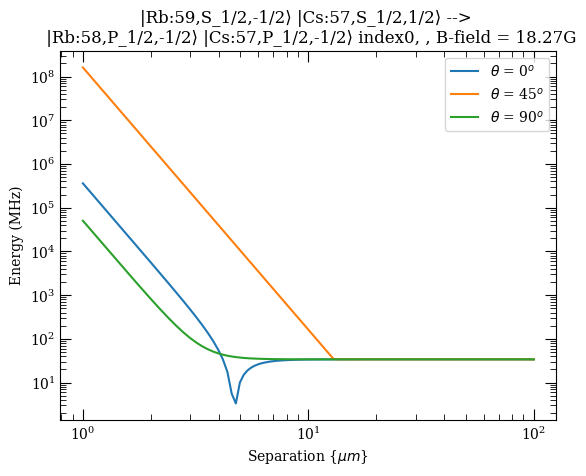

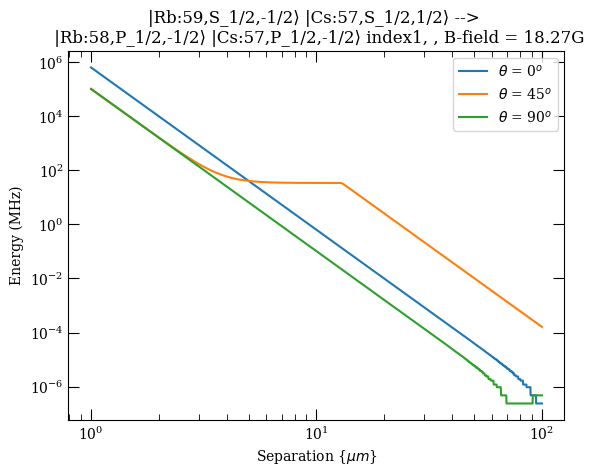

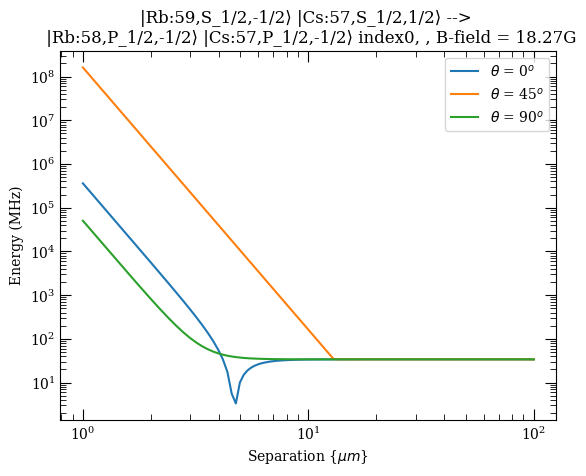

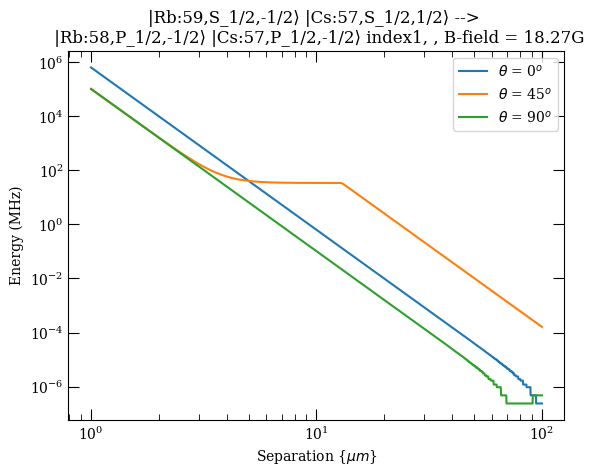

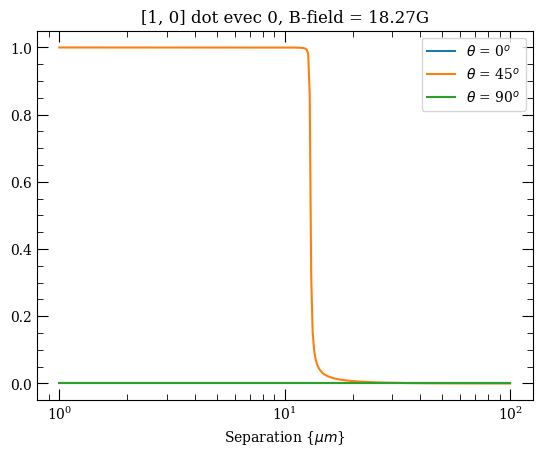

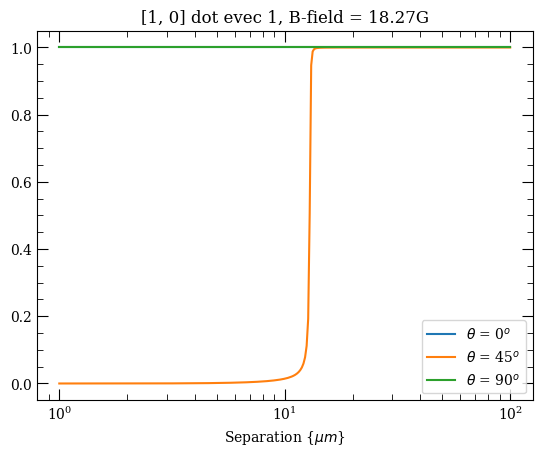

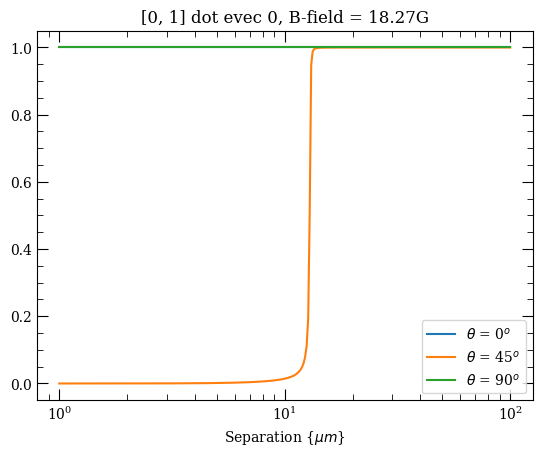

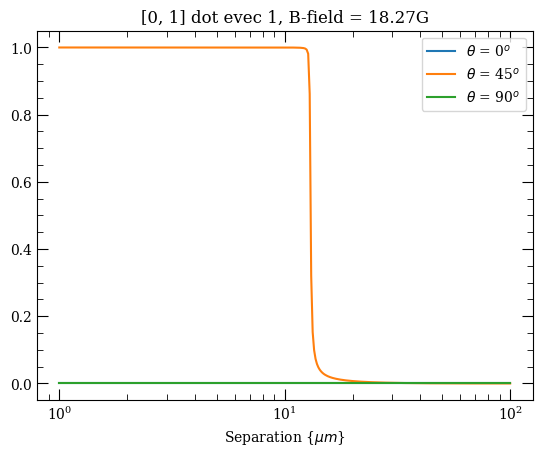

In [32]:
b=bs[4]
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = [[1,0], [0,1]]

overlap = {f'{b}{theta}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{b}{theta}']] for index in range(2) for tup in tups} for b in bs for theta in thetas}

Ediag = {f'{b}{theta}' : {f'{index}{tup}' : [eval[index] for eval in eval_list[f'{b}{theta}']] for index in range(2) for tup in tups} for b in bs for theta in thetas}

r = 10

for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        ax.set_yscale('log')
        ax.set_xscale('log')
        for theta in thetas:         
            ax.plot(rs[f'{b}{theta}'], abs(np.array(Ediag[f'{b}{theta}'][f'{index}{tup}'])), "-", label = fr'$\theta$ = {theta}$^o$')

        ax.legend()
        ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, , B-field = {np.round(b,2)}G')
        ax.set_ylabel('Energy (MHz)')
        ax.set_xlabel(r"Separation {$\mu m$}")
        plt.savefig(figpath + f'eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), mag {b}G, e {np.round(e,1)}Vcm evec {index}.png')

    plt.show()


for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        ax.set_xscale('log')

        for theta in thetas:         
            ax.plot(rs[f'{b}{theta}'], overlap[f'{b}{theta}'][f'{index}{tup}'], label = fr'$\theta$ = {theta}$^o$') 
        ax.legend()
        ax.set_xlabel(r"Separation {$\mu m$}")
        ax.set_title(f'{tup} dot evec {index}, B-field = {np.round(b,2)}G')
        
        plt.savefig(figpath + f'overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), mag {b}G, e {np.round(e,1)}Vcm evec {index}.png')

In [ ]:
theta = thetas[0]
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = [[1,0], [0,1]]

overlap = {f'{b}{theta}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{b}{theta}']] for index in range(2) for tup in tups} for b in bs for theta in thetas}

Ediag = {f'{b}{theta}' : {f'{index}{tup}' : [eval[index] for eval in eval_list[f'{b}{theta}']] for index in range(2) for tup in tups} for b in bs for theta in thetas}

for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        ax.set_yscale('log')
        ax.set_xscale('log')
        for b in bs:         
            ax.plot(rs[f'{b}{theta}'], abs(np.array(Ediag[f'{b}{theta}'][f'{index}{tup}'])), "-", label = fr'B-field = {b}G')

        ax.legend()
        ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, mag {b}G')
        ax.set_ylabel('Energy (MHz)')
        ax.set_xlabel(r"Separation {$\mu m$}")
        plt.savefig(figpath + f'overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {theta}deg, e {np.round(e,1)}Vcm evec {index}.png')

    plt.show()


for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        ax.set_xscale('log')

        for theta in thetas:         
            ax.plot(rs[f'{b}{theta}'], overlap[f'{b}{theta}'][f'{index}{tup}'], label = fr'B-field = {b}G') 
        ax.legend()
        ax.set_xlabel(r"Separation {$\mu m$}")
        ax.set_title(f'{tup} dot evec {index}, sep {r}um')
        
        plt.savefig(figpath + f'\\eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {theta}deg, e {np.round(e,1)}Vcm evec {index}.png')

{'0': {'0.0': [-69533.65004911122, -23527.25810723422, -9431.718854557692, -4294.3818049275005, -2164.2701532373094, -1187.9417234565822, -702.5654181663285, -444.07196149127014, -297.7919140866039, -210.336015654567, -155.36833026940695, -119.23101636533835, -94.51056020064955, -77.00660104474156, -64.24081553813924, -54.69427464499119, -47.40271364154925, -41.733938146566025, -37.2611321704495, -33.68836023021528, -30.805402887880703, -28.459592340658418, -26.537788628645643, -24.95457932861217, -23.644384902825912, -22.55608412461126, -21.64928792058148, -20.891718131651004, -20.25732824482478, -19.724938772200495, -19.277223438941085, -18.89994538494018, -18.581364789478624, -18.311780362334012, -18.083158572076442, -17.888839338105214, -17.723294896450447, -17.58193035999809, -17.460923994934696, -17.357091782322435, -17.267777956775745, -17.190763638308656, -17.12419343509701, -17.0665109353399, -17.01640945403251, -16.97278947814074, -16.93472391300849, -16.901429366863816, -16.

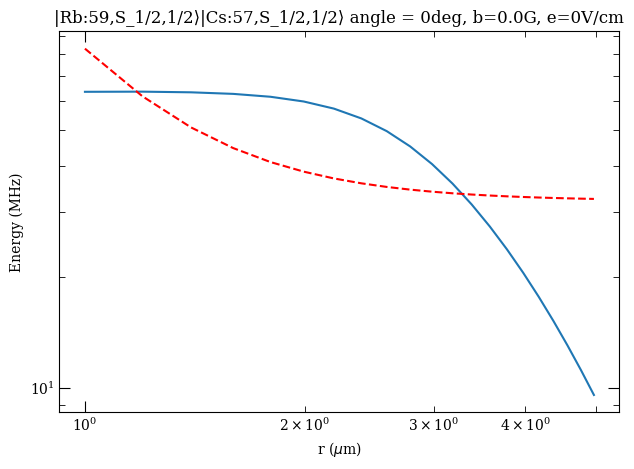

In [86]:
mag = bs[0]
ds = np.array(rs[f'{mag}'])
index=1
print(Ediags)
energy = abs(np.array(Ediags[f'{index}'][f'{mag}']))
rmax=5
mj1_0, mj2_0 = -1/2, -1/2

import os
figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\eff log fitted\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\eff log fitted\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

def func(r, c, a):
    return c/(r)**3 + a


ds = ds[np.argwhere(ds<rmax)].flatten()
energy = energy[np.argwhere(ds<rmax)].flatten()

print(len(ds), len(energy))
popt, pcov = curve_fit(func, ds, energy)
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r"r ($\mu$m)")
ax.set_ylabel(f"Energy ({energy_unit})")
ax.set_title(fr'separations $\mu$m')
plt.tight_layout()
plt.title(fr'{str(ket1)}{str(ket2)} angle = {theta}deg, b={mag}G, e={elec}V/cm')

ax.plot(ds, abs(energy))
ax.plot(ds, abs(func(ds, *popt)), linestyle='dashed', color='red')
fig.savefig(figpath + f'deg{theta} b{mag}G e{elec}Vcm mjs{mj1_0},{mj2_0}.png')
print(pcov)
C3 = pd.DataFrame({'c3' : [popt[0]], 'error' : [np.sqrt(np.diag(pcov))[0]]})
C3.to_csv(datapath + f'deg{theta} b{mag}G e{elec}Vcm mjs{mj1_0},{mj2_0}.csv', index=False)

print(popt)